# 🌾 Advanced Crop Recommendation System
> **Goal:** Build a high-accuracy ensemble model using features: `N, temperature, humidity, ph, rainfall`  
> **Stack:** XGBoost + LightGBM + Random Forest → Voting Ensemble  
> **Target:** Maximize accuracy while reducing similar-crop confusions


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, PowerTransformer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    VotingClassifier, StackingClassifier, ExtraTreesClassifier
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.inspection import permutation_importance

# Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Save
import joblib, os

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_theme(style='whitegrid', palette='muted')

print('✅ All libraries loaded successfully')


✅ All libraries loaded successfully


###  2. Load & Inspect Data

In [2]:
# ── Change this path to your CSV location ──
DATA_PATH = r"C:\Users\debas\OneDrive\Desktop\Final Year Project\Main_prj\new ds\crop_recomendation\Crop_recommendation.csv"

df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head()


Shape: (2200, 8)


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [3]:
print('=== Basic Info ===')
print(f'Rows: {df.shape[0]}, Cols: {df.shape[1]}')
print(f'Classes: {df["label"].nunique()} crops')
print(f'Missing values:\n{df.isnull().sum()}')
print('\n=== Class Counts ===')
print(df['label'].value_counts())


=== Basic Info ===
Rows: 2200, Cols: 8
Classes: 22 crops
Missing values:
N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

=== Class Counts ===
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


### 3. EDA

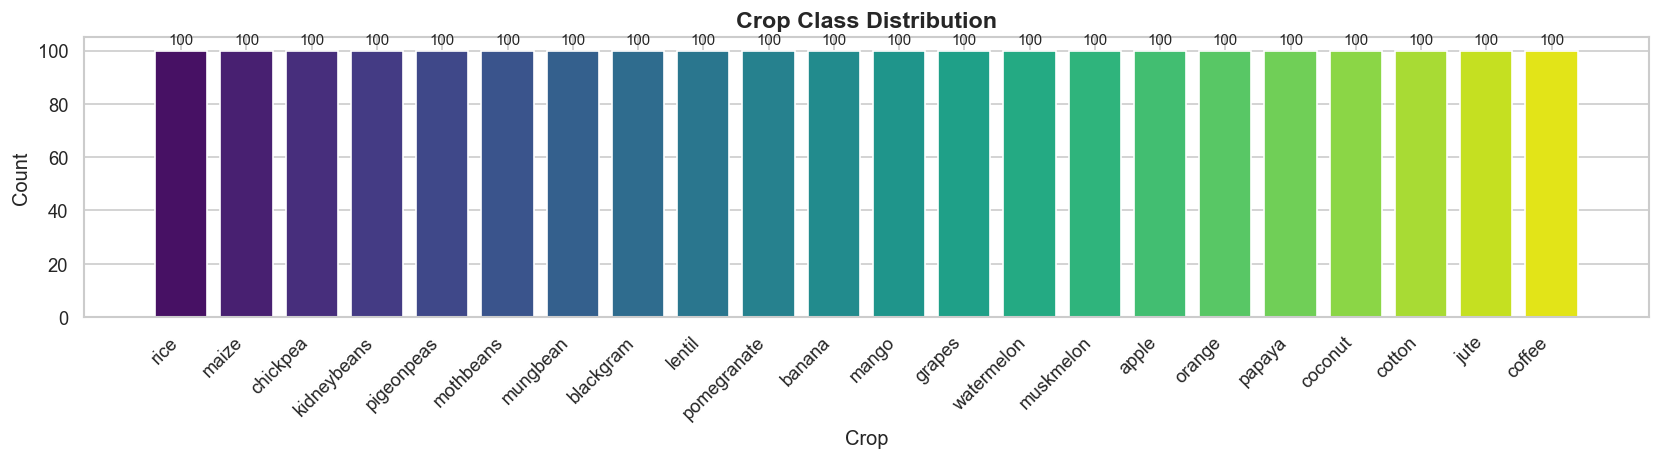

In [4]:
# 3.1 — Class Distribution
fig, ax = plt.subplots(figsize=(14, 4))
counts = df['label'].value_counts()
bars = ax.bar(counts.index, counts.values,
              color=sns.color_palette('viridis', len(counts)))
ax.bar_label(bars, padding=2, fontsize=9)
ax.set_title('Crop Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Crop')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


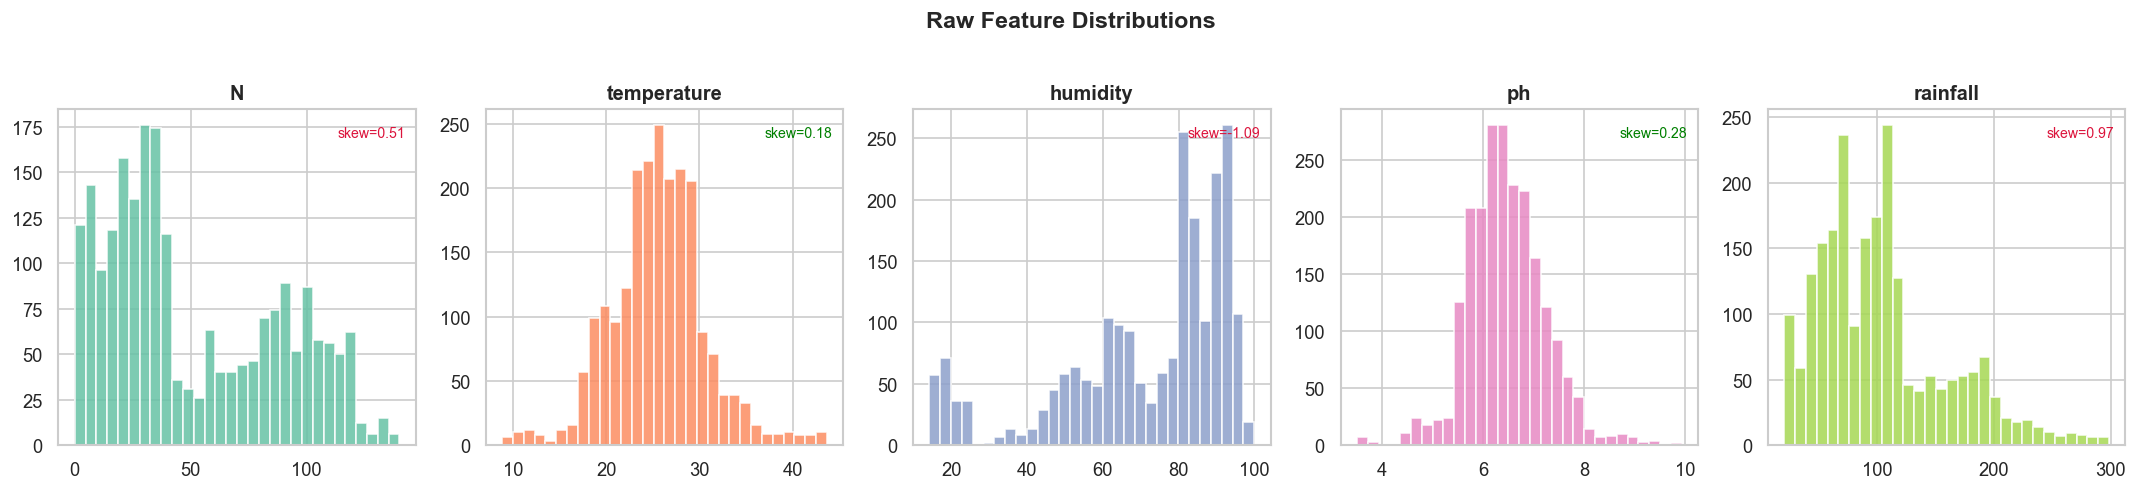

In [5]:
# 3.2 — Feature Distributions (raw)
FEATURES = ['N', 'temperature', 'humidity', 'ph', 'rainfall']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
colors = sns.color_palette('Set2', 5)
for i, (feat, ax, c) in enumerate(zip(FEATURES, axes, colors)):
    ax.hist(df[feat], bins=30, color=c, edgecolor='white', alpha=0.85)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('')
    skew_val = df[feat].skew()
    ax.text(0.97, 0.95, f'skew={skew_val:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8.5,
            color='crimson' if abs(skew_val) > 0.5 else 'green')
plt.suptitle('Raw Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


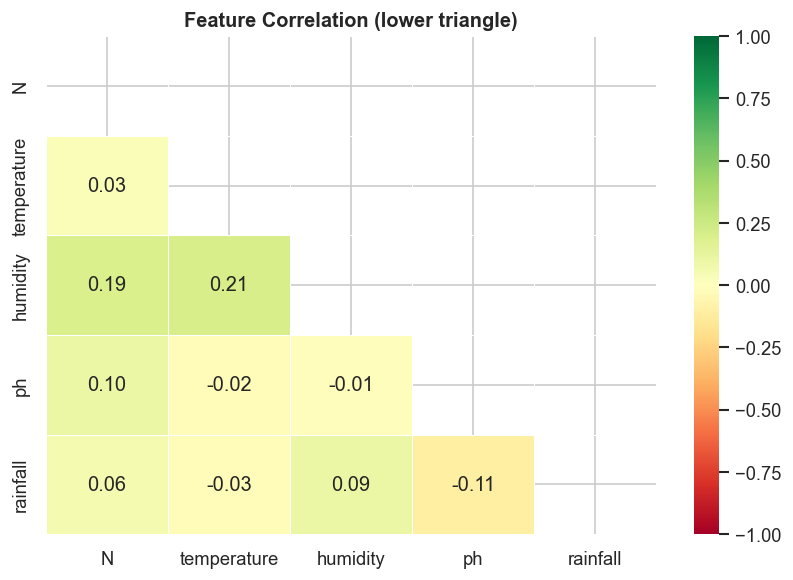

In [6]:
# 3.3 — Feature Correlation Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Feature Correlation (lower triangle)', fontweight='bold')
plt.tight_layout()
plt.show()


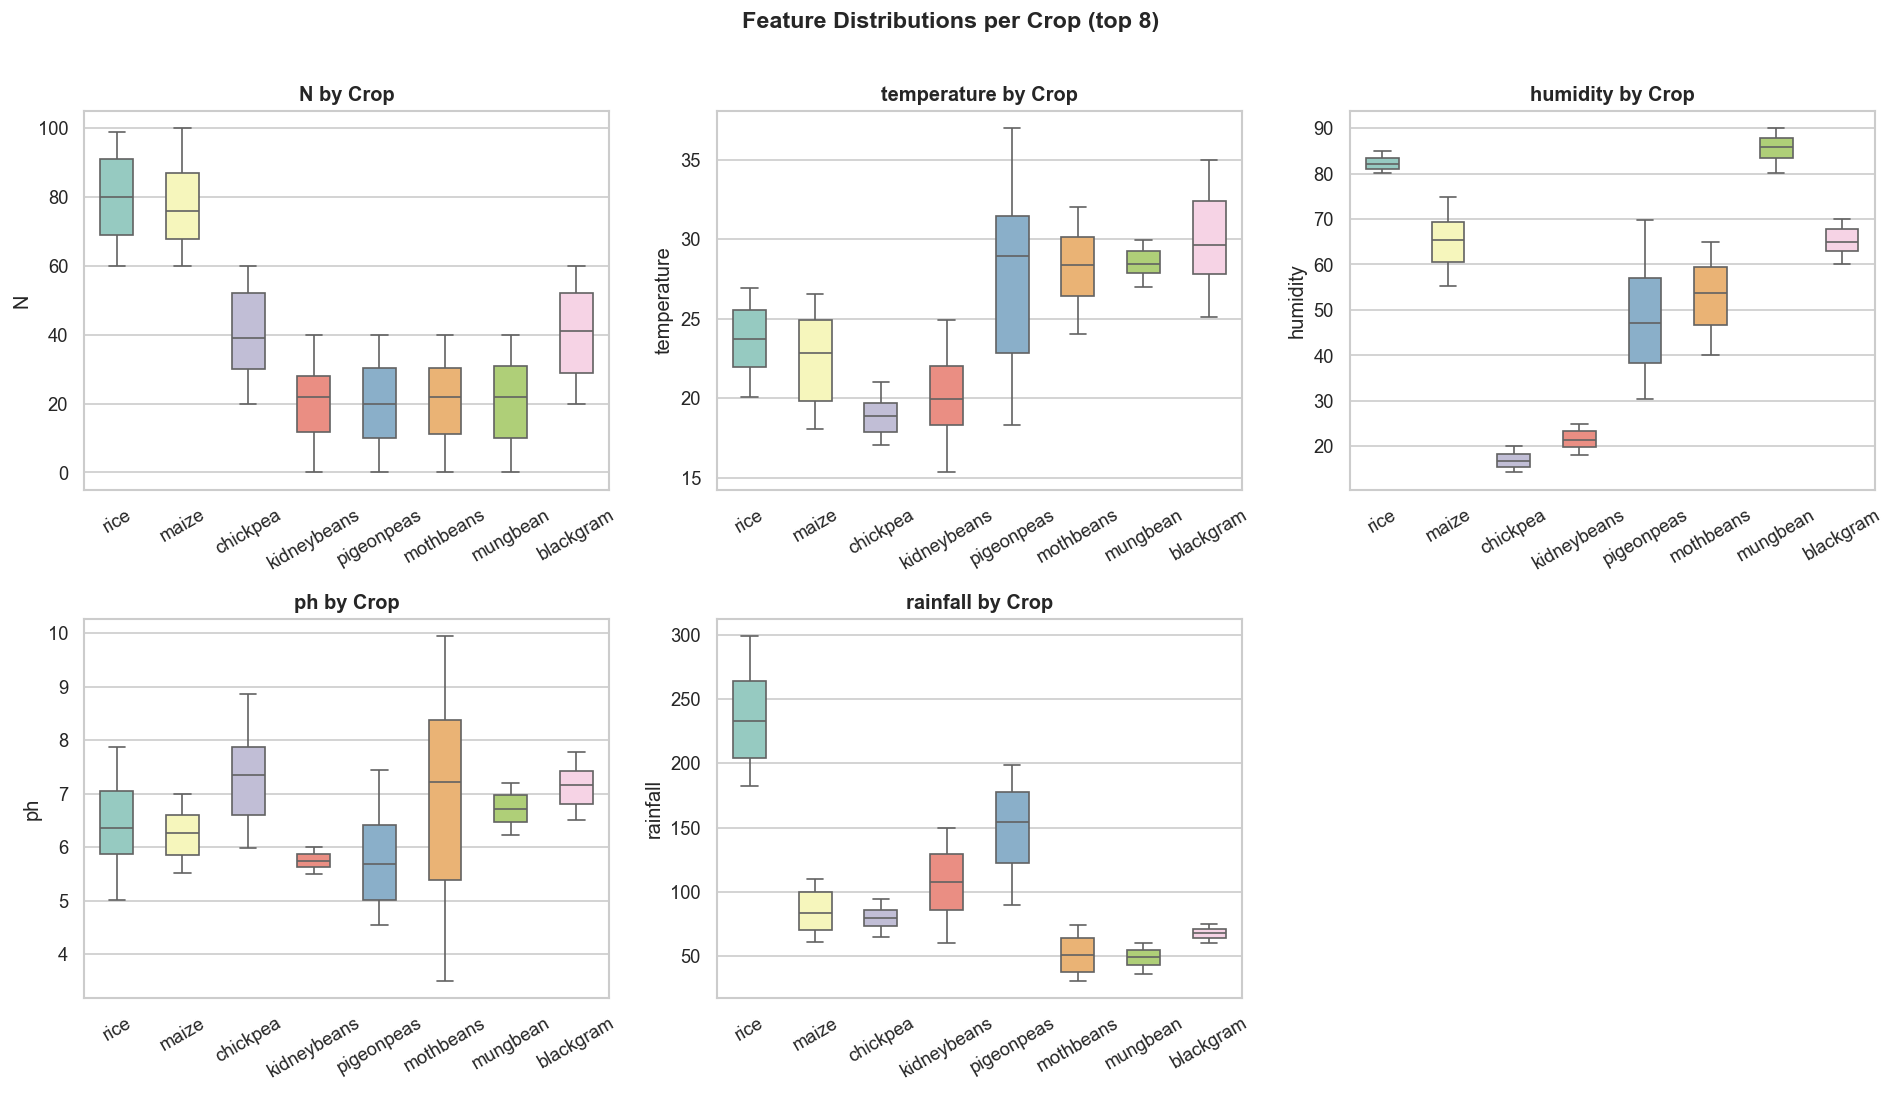

In [7]:
# 3.4 — Boxplots per Feature (top 8 crops for clarity)
top_crops = df['label'].value_counts().head(8).index.tolist()
df_top = df[df['label'].isin(top_crops)]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, feat in enumerate(FEATURES):
    sns.boxplot(data=df_top, x='label', y=feat, ax=axes[i],
                palette='Set3', width=0.5, fliersize=2)
    axes[i].set_title(f'{feat} by Crop', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
axes[-1].set_visible(False)
plt.suptitle('Feature Distributions per Crop (top 8)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


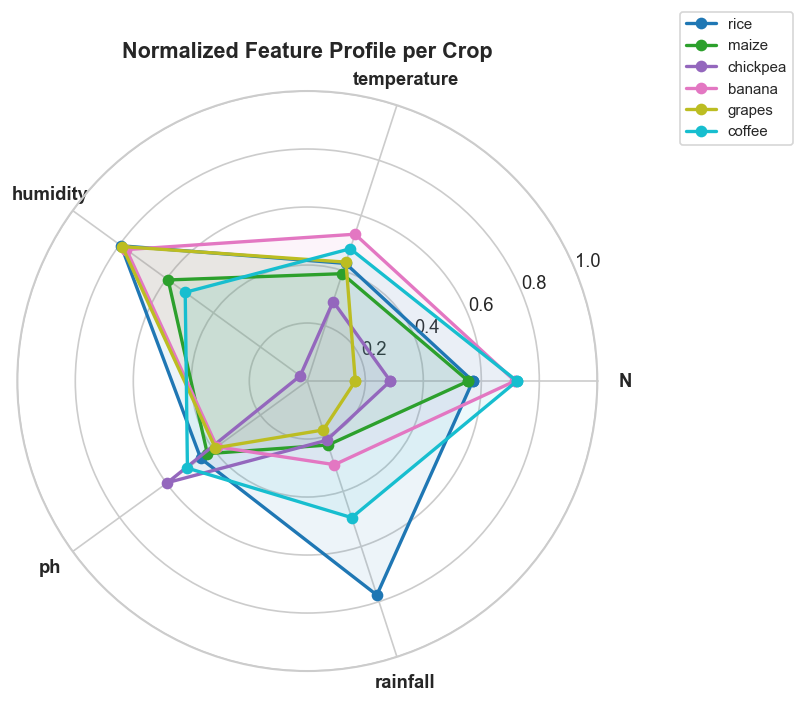

In [8]:
# 3.5 — Radar Chart: Average Feature Profile per crop
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normalize features 0-1 for radar
df_norm = df.copy()
for f in FEATURES:
    df_norm[f] = (df[f] - df[f].min()) / (df[f].max() - df[f].min())

crop_means = df_norm.groupby('label')[FEATURES].mean()

# Pick 6 representative crops
selected = ['rice', 'maize', 'chickpea', 'banana', 'grapes', 'coffee']
selected = [c for c in selected if c in crop_means.index]

N_feat = len(FEATURES)
angles = [n / float(N_feat) * 2 * np.pi for n in range(N_feat)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0, 1, len(selected)))

for crop, color in zip(selected, colors):
    values = crop_means.loc[crop].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=crop, color=color)
    ax.fill(angles, values, alpha=0.08, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(FEATURES, fontsize=11, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_title('Normalized Feature Profile per Crop', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()


### 4. Feature Eng. and Proccessing

In [9]:
# 4.1 — Use only the 5 allowed features
FEATURES = ['N', 'temperature', 'humidity', 'ph', 'rainfall']

X_raw = df[FEATURES].copy()
y_raw = df['label'].copy()

# Label encode
le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f'Classes: {le.classes_}')


Classes: ['apple' 'banana' 'blackgram' 'chickpea' 'coconut' 'coffee' 'cotton'
 'grapes' 'jute' 'kidneybeans' 'lentil' 'maize' 'mango' 'mothbeans'
 'mungbean' 'muskmelon' 'orange' 'papaya' 'pigeonpeas' 'pomegranate'
 'rice' 'watermelon']


In [10]:
# 4.2 — Engineered Features (interactions & ratios)
def add_features(X):
    X = X.copy()
    # Humidity × Temperature → heat-moisture stress index
    X['humidity_temp'] = X['humidity'] * X['temperature']
    # Rainfall / (temperature + 1) → moisture efficiency
    X['rain_temp_ratio'] = X['rainfall'] / (X['temperature'] + 1)
    # ph deviation from neutral (7)
    X['ph_dev'] = (X['ph'] - 7).abs()
    # N × humidity → nitrogen availability under moisture
    X['N_humidity'] = X['N'] * X['humidity']
    # Log-transform heavy-tailed features
    X['log_rainfall'] = np.log1p(X['rainfall'])
    X['log_N'] = np.log1p(X['N'])
    return X

X_eng = add_features(X_raw)
ENG_FEATURES = X_eng.columns.tolist()
print(f'Total features after engineering: {len(ENG_FEATURES)}')
print(ENG_FEATURES)


Total features after engineering: 11
['N', 'temperature', 'humidity', 'ph', 'rainfall', 'humidity_temp', 'rain_temp_ratio', 'ph_dev', 'N_humidity', 'log_rainfall', 'log_N']


In [11]:
# 4.3 — Train/Val/Test split (70/15/15) — stratified
X_temp, X_test, y_temp, y_test = train_test_split(
    X_eng, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp  # 0.176 of 0.85 ≈ 0.15
)

print(f'Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}')


Train: 1540  Val: 330  Test: 330


In [15]:
# 4.4 — PowerTransformer (Yeo-Johnson) → Gaussian-ize skewed features
skewed_cols = ['N', 'humidity', 'rainfall', 'N_humidity', 'rain_temp_ratio',
               'log_rainfall', 'log_N']

pt = PowerTransformer(method='yeo-johnson', standardize=True)

X_train_sc = X_train.copy()
X_val_sc   = X_val.copy()
X_test_sc  = X_test.copy()

X_train_sc[skewed_cols] = pt.fit_transform(X_train[skewed_cols])
X_val_sc[skewed_cols]   = pt.transform(X_val[skewed_cols])
X_test_sc[skewed_cols]  = pt.transform(X_test[skewed_cols])

# Standard scale remaining features
scaler = StandardScaler()
other_cols = [c for c in ENG_FEATURES if c not in skewed_cols]
X_train_sc[other_cols] = scaler.fit_transform(X_train[other_cols])
X_val_sc[other_cols]   = scaler.transform(X_val[other_cols])
X_test_sc[other_cols]  = scaler.transform(X_test[other_cols])

print('✅ Preprocessing complete')
print(f'Skew after transform (N): {X_train_sc["N"].skew():.3f}')


✅ Preprocessing complete
Skew after transform (N): -0.126


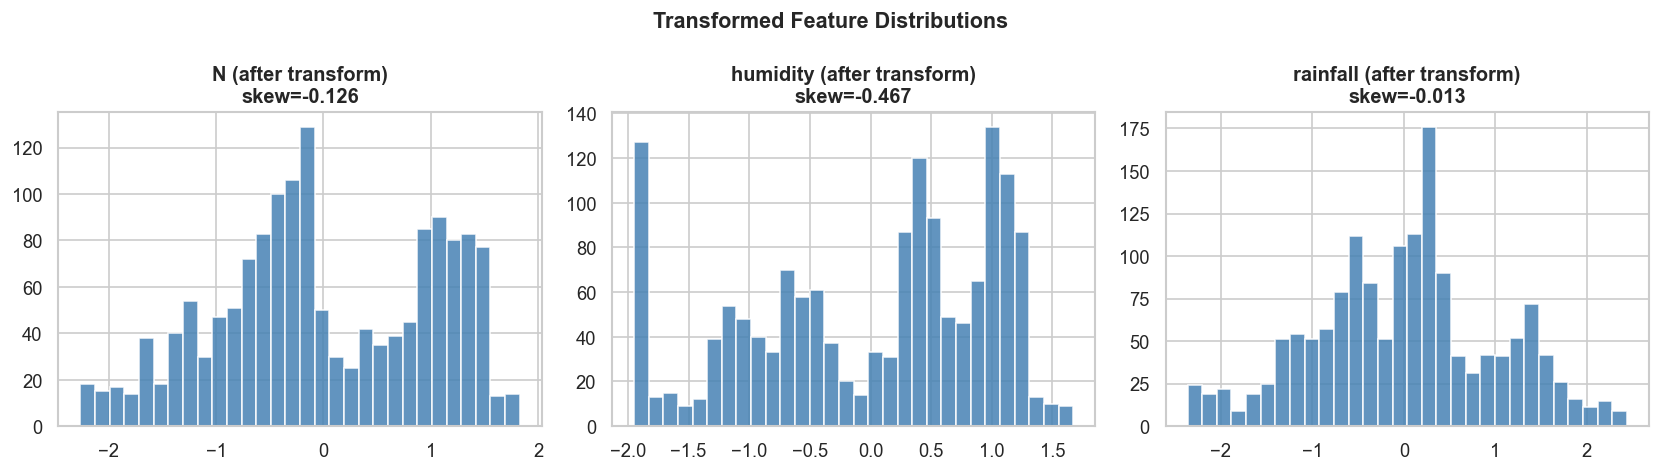

In [16]:
# 4.5 — Distribution after transform
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feat in zip(axes, ['N', 'humidity', 'rainfall']):
    ax.hist(X_train_sc[feat], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'{feat} (after transform)\nskew={X_train_sc[feat].skew():.3f}', fontweight='bold')
plt.suptitle('Transformed Feature Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### 5. Model Training -- Individual Models

In [17]:
# Helper: cross-validate and report
def cv_eval(model, X, y, cv=5, name='Model'):
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=skf, scoring='accuracy', n_jobs=-1)
    print(f'{name:30s} → CV Mean: {scores.mean():.4f}  Std: {scores.std():.4f}')
    return scores


In [18]:
# 5.1 — XGBoost (tuned)
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.5,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train_sc, y_train,
    eval_set=[(X_val_sc, y_val)],
    verbose=False
)

print('XGBoost Val Accuracy:', accuracy_score(y_val, xgb.predict(X_val_sc)))


XGBoost Val Accuracy: 0.9757575757575757


In [19]:
# 5.2 — LightGBM (tuned)
lgbm = LGBMClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=40,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=10,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgbm.fit(
    X_train_sc, y_train,
    eval_set=[(X_val_sc, y_val)]
)

print('LightGBM Val Accuracy:', accuracy_score(y_val, lgbm.predict(X_val_sc)))


LightGBM Val Accuracy: 0.9696969696969697


In [20]:
# 5.3 — Random Forest (tuned)
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    max_features='sqrt',
    min_samples_split=4,
    min_samples_leaf=2,
    bootstrap=True,
    oob_score=True,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sc, y_train)

print('Random Forest Val Accuracy:', accuracy_score(y_val, rf.predict(X_val_sc)))
print(f'OOB Score: {rf.oob_score_:.4f}')


Random Forest Val Accuracy: 0.9848484848484849
OOB Score: 0.9688


In [21]:
# 5.4 — Extra Trees
et = ExtraTreesClassifier(
    n_estimators=500,
    max_features='sqrt',
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
et.fit(X_train_sc, y_train)

print('Extra Trees Val Accuracy:', accuracy_score(y_val, et.predict(X_val_sc)))


Extra Trees Val Accuracy: 0.9696969696969697


In [22]:
# 5.5 — Compare all with 5-Fold CV
X_full = pd.concat([X_train_sc, X_val_sc])
y_full = np.concatenate([y_train, y_val])

results = {}
for name, model in [('XGBoost', xgb), ('LightGBM', lgbm),
                     ('RandomForest', rf), ('ExtraTrees', et)]:
    scores = cv_eval(model, X_full, y_full, cv=5, name=name)
    results[name] = scores


XGBoost                        → CV Mean: 0.9642  Std: 0.0080
LightGBM                       → CV Mean: 0.9668  Std: 0.0075
RandomForest                   → CV Mean: 0.9727  Std: 0.0060
ExtraTrees                     → CV Mean: 0.9647  Std: 0.0049


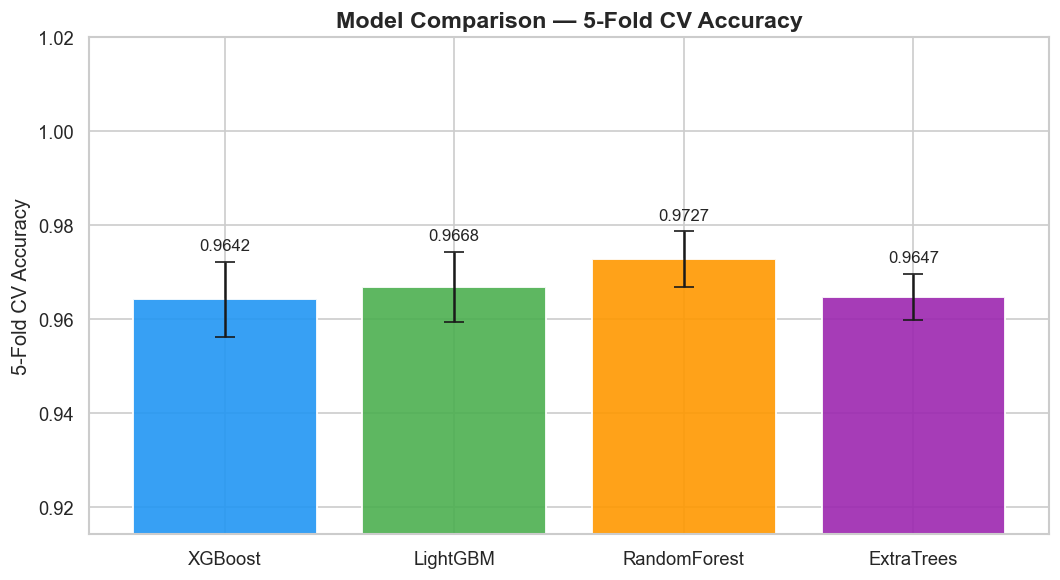

In [23]:
# 5.6 — CV Score Comparison Chart
fig, ax = plt.subplots(figsize=(9, 5))
names = list(results.keys())
means = [s.mean() for s in results.values()]
stds  = [s.std()  for s in results.values()]

colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bars = ax.bar(names, means, yerr=stds, capsize=6, color=colors,
              edgecolor='white', linewidth=1.2, alpha=0.9)
ax.bar_label(bars, labels=[f'{m:.4f}' for m in means], padding=5, fontsize=10)
ax.set_ylim(min(means) - 0.05, 1.02)
ax.set_ylabel('5-Fold CV Accuracy', fontsize=12)
ax.set_title('Model Comparison — 5-Fold CV Accuracy', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



### 6. Stacking Ensemble (Meta Lerner)

In [24]:
# Stacking: XGB + LGBM + RF + ET → meta XGBoost
from sklearn.linear_model import LogisticRegression

estimators = [
    ('xgb',  XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.07,
                            subsample=0.8, colsample_bytree=0.8,
                            eval_ametric='mlogloss', use_label_encoder=False,
                            random_state=42, n_jobs=-1, verbose=0)),
    ('lgbm', LGBMClassifier(n_estimators=300, max_depth=5, learning_rate=0.07,
                             num_leaves=35, subsample=0.8, colsample_bytree=0.8,
                             random_state=42, n_jobs=-1, verbose=-1)),
    ('rf',   RandomForestClassifier(n_estimators=300, max_features='sqrt',
                                    min_samples_leaf=2, oob_score=False,
                                    random_state=42, n_jobs=-1)),
    ('et',   ExtraTreesClassifier(n_estimators=300, max_features='sqrt',
                                   min_samples_leaf=2, random_state=42, n_jobs=-1)),
]

# Meta-learner: calibrated logistic regression
meta = LogisticRegression(C=5, max_iter=1000, random_state=42)

stacker = StackingClassifier(
    estimators=estimators,
    final_estimator=meta,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
    passthrough=True   # also passes original features to meta-learner
)

stacker.fit(X_train_sc, y_train)

y_pred_stack = stacker.predict(X_test_sc)
acc_stack = accuracy_score(y_test, y_pred_stack)
print(f'\n🏆 Stacking Ensemble Test Accuracy: {acc_stack:.4f}')



🏆 Stacking Ensemble Test Accuracy: 0.9606


### 7. Final Evaluation on Hold-out Test Set

In [25]:
# Evaluate all models on test set
model_dict = {
    'XGBoost':      (xgb,     X_test_sc),
    'LightGBM':     (lgbm,    X_test_sc),
    'RandomForest': (rf,      X_test_sc),
    'ExtraTrees':   (et,      X_test_sc),
    'Stacking':     (stacker, X_test_sc),
}

test_scores = {}
for name, (m, Xte) in model_dict.items():
    acc = accuracy_score(y_test, m.predict(Xte))
    test_scores[name] = acc
    print(f'{name:20s}: {acc:.4f}')


XGBoost             : 0.9576
LightGBM            : 0.9697
RandomForest        : 0.9545
ExtraTrees          : 0.9545
Stacking            : 0.9606


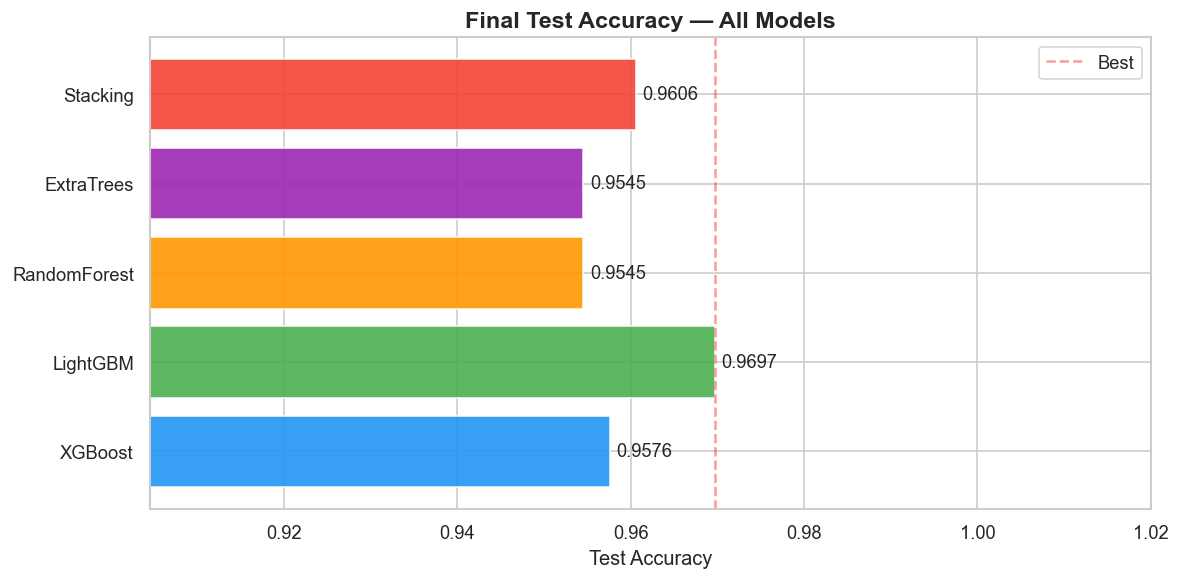

In [26]:
# 7.1 — Test Accuracy Bar Chart
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(test_scores.keys())
values = list(test_scores.values())
palette = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
bars = ax.barh(names, values, color=palette, edgecolor='white', alpha=0.9)
ax.bar_label(bars, labels=[f'{v:.4f}' for v in values], padding=4, fontsize=11)
ax.set_xlim(min(values) - 0.05, 1.02)
ax.set_xlabel('Test Accuracy', fontsize=12)
ax.set_title('Final Test Accuracy — All Models', fontsize=14, fontweight='bold')
ax.axvline(x=max(values), color='red', linestyle='--', alpha=0.4, label='Best')
ax.legend()
plt.tight_layout()
plt.show()


In [27]:
# 7.2 — Full Classification Report (Best Model)
best_name = max(test_scores, key=test_scores.get)
best_model, best_X = model_dict[best_name]

print(f'\n=== Classification Report — {best_name} ===')
print(classification_report(
    y_test, best_model.predict(best_X),
    target_names=le.classes_
))



=== Classification Report — LightGBM ===
              precision    recall  f1-score   support

       apple       0.79      1.00      0.88        15
      banana       1.00      0.93      0.97        15
   blackgram       1.00      1.00      1.00        15
    chickpea       1.00      1.00      1.00        15
     coconut       1.00      1.00      1.00        15
      coffee       1.00      1.00      1.00        15
      cotton       0.94      1.00      0.97        15
      grapes       1.00      1.00      1.00        15
        jute       1.00      1.00      1.00        15
 kidneybeans       1.00      1.00      1.00        15
      lentil       0.94      1.00      0.97        15
       maize       1.00      1.00      1.00        15
       mango       1.00      1.00      1.00        15
   mothbeans       1.00      0.93      0.97        15
    mungbean       1.00      1.00      1.00        15
   muskmelon       1.00      1.00      1.00        15
      orange       0.87      0.87      

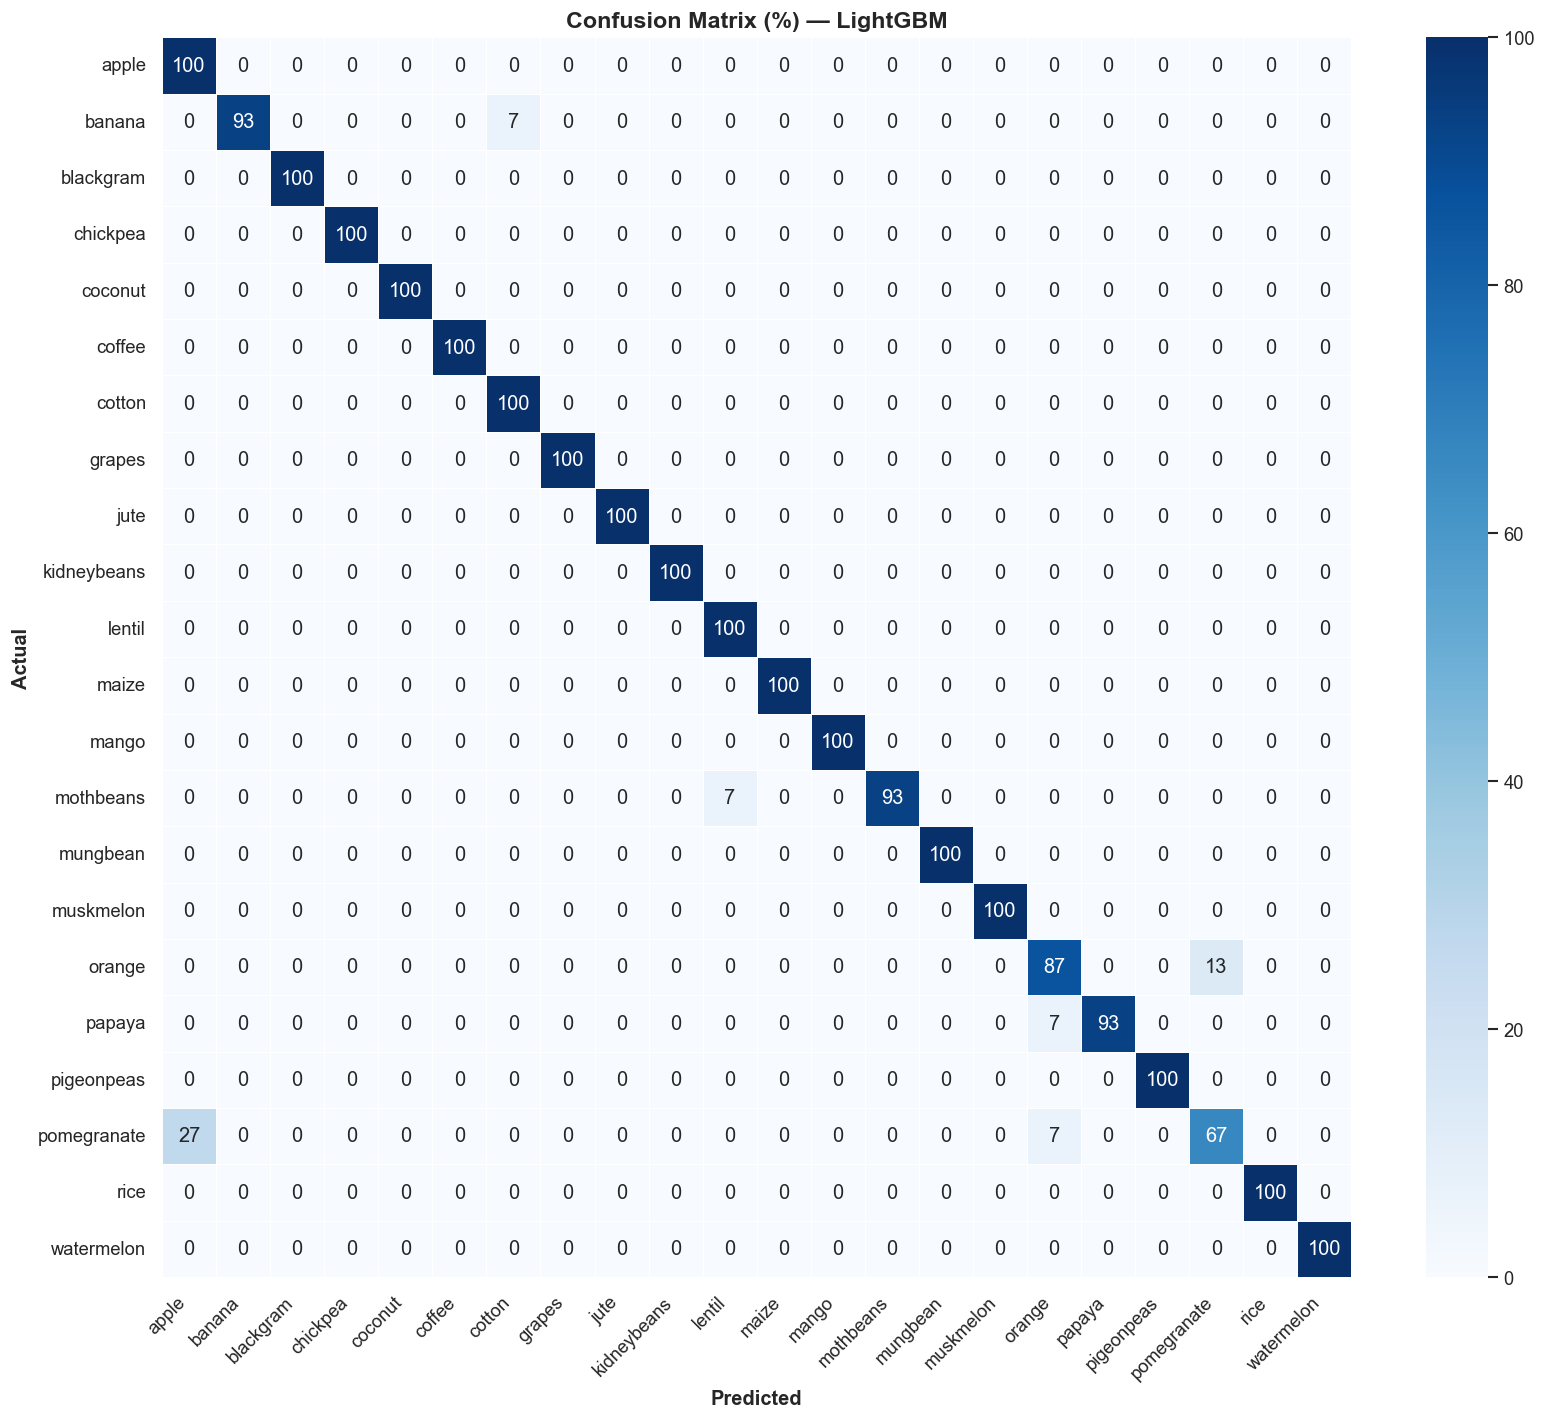

In [28]:
# 7.3 — Confusion Matrix Heatmap
cm = confusion_matrix(y_test, best_model.predict(best_X))
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_pct, annot=True, fmt='.0f', cmap='Blues',
    xticklabels=le.classes_, yticklabels=le.classes_,
    linewidths=0.4, ax=ax, vmin=0, vmax=100
)
ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
ax.set_title(f'Confusion Matrix (%) — {best_name}', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


### 8. Feature Importance Analysis

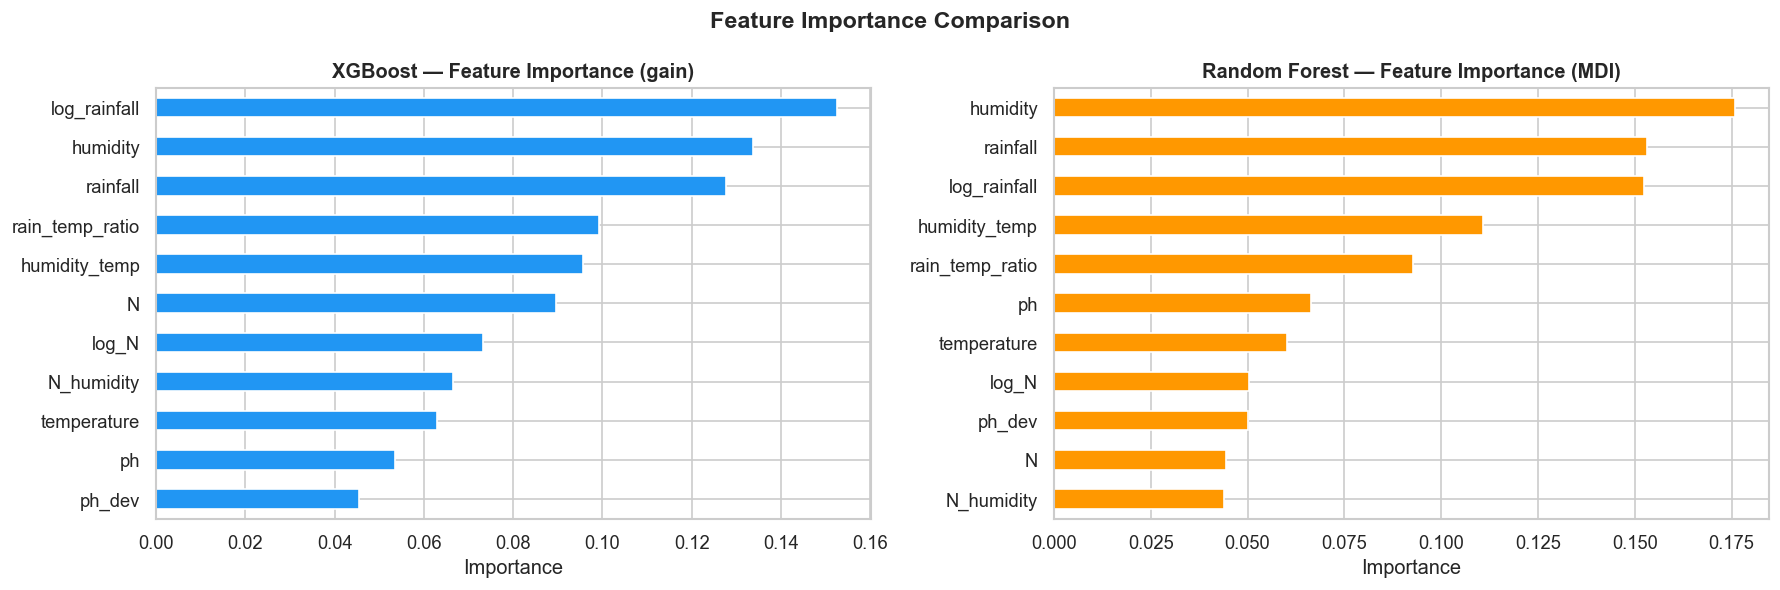

In [29]:
# 8.1 — XGBoost Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# XGBoost
xgb_imp = pd.Series(xgb.feature_importances_, index=ENG_FEATURES).sort_values()
xgb_imp.plot(kind='barh', ax=axes[0], color='#2196F3', edgecolor='white')
axes[0].set_title('XGBoost — Feature Importance (gain)', fontweight='bold')
axes[0].set_xlabel('Importance')

# Random Forest
rf_imp = pd.Series(rf.feature_importances_, index=ENG_FEATURES).sort_values()
rf_imp.plot(kind='barh', ax=axes[1], color='#FF9800', edgecolor='white')
axes[1].set_title('Random Forest — Feature Importance (MDI)', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


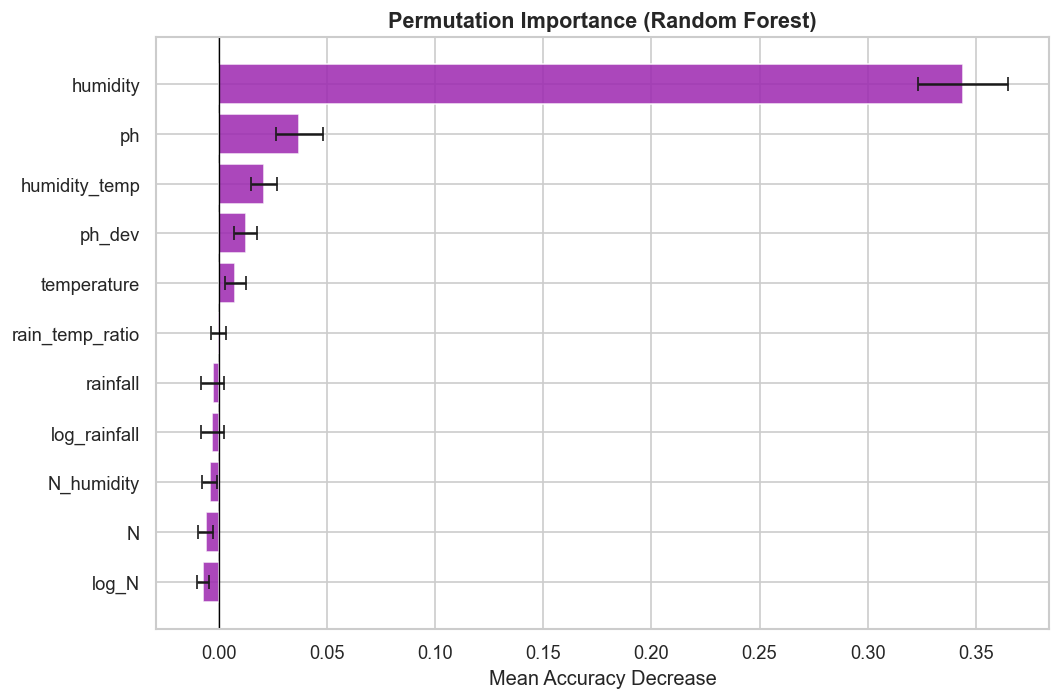

In [30]:
# 8.2 — Permutation Importance (model-agnostic, more reliable)
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf, X_test_sc, y_test, n_repeats=20, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': ENG_FEATURES,
    'Mean':    perm.importances_mean,
    'Std':     perm.importances_std
}).sort_values('Mean', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_df['Feature'], perm_df['Mean'],
        xerr=perm_df['Std'], capsize=4,
        color='#9C27B0', edgecolor='white', alpha=0.85)
ax.set_title('Permutation Importance (Random Forest)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Accuracy Decrease')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


### 9. Prediction with Confidence Score

In [35]:
def predict_crop(N, temperature, humidity, ph, rainfall, model, top_k=3):
    """
    Predict crop with top-k recommendations and confidence scores.
    Inputs: raw 5 features
    """
    raw = pd.DataFrame([[N, temperature, humidity, ph, rainfall]],
                       columns=['N', 'temperature', 'humidity', 'ph', 'rainfall'])
    
    # Same feature engineering
    X_input = add_features(raw)
    
    # Same preprocessing
    X_input[skewed_cols] = pt.transform(X_input[skewed_cols])
    X_input[other_cols]  = scaler.transform(X_input[other_cols])
    
    # Probabilities
    proba = model.predict_proba(X_input)[0]
    top_idx = np.argsort(proba)[::-1][:top_k]
    
    print('\n🌾 Crop Recommendation Results')
    print('='*40)
    for rank, idx in enumerate(top_idx, 1):
        crop = le.classes_[idx]
        conf = proba[idx] * 100
        bar  = '█' * int(conf / 5) + '░' * (20 - int(conf / 5))
        print(f'  #{rank} {crop:<15} {bar} {conf:.1f}%')
    print('='*40)
    return le.classes_[top_idx[0]], proba[top_idx[0]]


# ── Example prediction ──
predict_crop(
    N=90, temperature=25, humidity=80, ph=6.5, rainfall=200,
    model=stacker
)



🌾 Crop Recommendation Results
  #1 rice            ████████████░░░░░░░░ 61.5%
  #2 jute            ███████░░░░░░░░░░░░░ 38.0%
  #3 coffee          ░░░░░░░░░░░░░░░░░░░░ 0.3%


('rice', np.float64(0.6145442115608795))

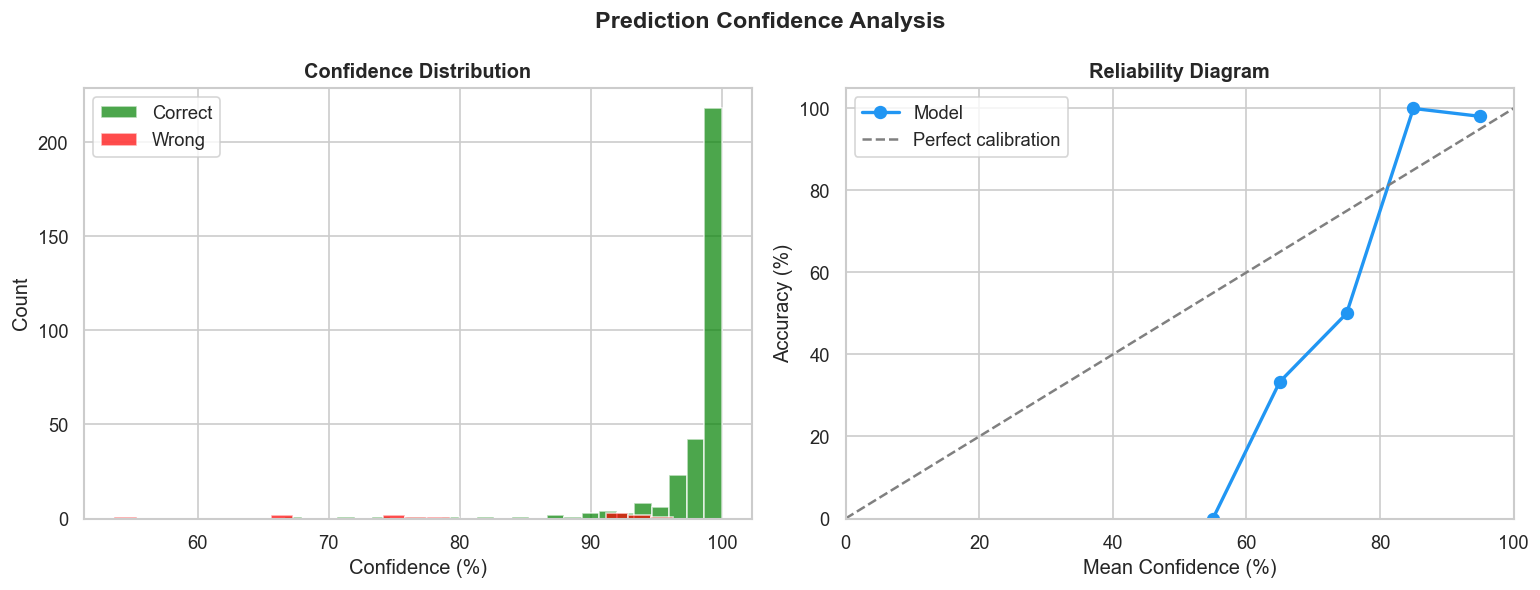

In [36]:
# 9.2 — Confidence Distribution on Test Set
proba_test = stacker.predict_proba(X_test_sc)
max_conf   = proba_test.max(axis=1) * 100
correct    = (stacker.predict(X_test_sc) == y_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram
axes[0].hist(max_conf[correct],  bins=25, alpha=0.7, color='green', label='Correct', edgecolor='white')
axes[0].hist(max_conf[~correct], bins=25, alpha=0.7, color='red',   label='Wrong',   edgecolor='white')
axes[0].set_xlabel('Confidence (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution', fontweight='bold')
axes[0].legend()

# Calibration-style: accuracy vs confidence bin
bins = np.linspace(0, 100, 11)
bin_acc = []
bin_center = []
for lo, hi in zip(bins[:-1], bins[1:]):
    mask = (max_conf >= lo) & (max_conf < hi)
    if mask.sum() > 0:
        bin_acc.append(correct[mask].mean() * 100)
        bin_center.append((lo + hi) / 2)

axes[1].plot(bin_center, bin_acc, 'o-', color='#2196F3', lw=2, ms=7, label='Model')
axes[1].plot([0, 100], [0, 100], '--', color='gray', label='Perfect calibration')
axes[1].set_xlabel('Mean Confidence (%)')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Reliability Diagram', fontweight='bold')
axes[1].legend()
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 105)

plt.suptitle('Prediction Confidence Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 10. Save Model Artifacts

In [37]:
os.makedirs('model', exist_ok=True)

joblib.dump(stacker,      'model/stacking_model.pkl')
joblib.dump(xgb,          'model/xgb_model.pkl')
joblib.dump(lgbm,         'model/lgbm_model.pkl')
joblib.dump(rf,           'model/rf_model.pkl')
joblib.dump(pt,           'model/power_transformer.pkl')
joblib.dump(scaler,       'model/standard_scaler.pkl')
joblib.dump(le,           'model/label_encoder.pkl')

# Save feature info
import json
meta = {
    'base_features': FEATURES,
    'all_features':  ENG_FEATURES,
    'skewed_cols':   skewed_cols,
    'other_cols':    other_cols,
    'classes':       le.classes_.tolist(),
    'best_model':    best_name,
    'test_accuracy': {k: round(v, 4) for k, v in test_scores.items()}
}
with open('model/metadata.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('✅ All artifacts saved to model/')
print(json.dumps(meta, indent=2))


✅ All artifacts saved to model/
{
  "base_features": [
    "N",
    "temperature",
    "humidity",
    "ph",
    "rainfall"
  ],
  "all_features": [
    "N",
    "temperature",
    "humidity",
    "ph",
    "rainfall",
    "humidity_temp",
    "rain_temp_ratio",
    "ph_dev",
    "N_humidity",
    "log_rainfall",
    "log_N"
  ],
  "skewed_cols": [
    "N",
    "humidity",
    "rainfall",
    "N_humidity",
    "rain_temp_ratio",
    "log_rainfall",
    "log_N"
  ],
  "other_cols": [
    "temperature",
    "ph",
    "humidity_temp",
    "ph_dev"
  ],
  "classes": [
    "apple",
    "banana",
    "blackgram",
    "chickpea",
    "coconut",
    "coffee",
    "cotton",
    "grapes",
    "jute",
    "kidneybeans",
    "lentil",
    "maize",
    "mango",
    "mothbeans",
    "mungbean",
    "muskmelon",
    "orange",
    "papaya",
    "pigeonpeas",
    "pomegranate",
    "rice",
    "watermelon"
  ],
  "best_model": "LightGBM",
  "test_accuracy": {
    "XGBoost": 0.9576,
    "LightGBM": 0.96

### 11. Summary

In [38]:
print('=' * 55)
print('  CROP RECOMMENDATION MODEL — FINAL SUMMARY')
print('=' * 55)
print(f'  Dataset size       : {df.shape[0]} samples, {df["label"].nunique()} crops')
print(f'  Input features     : {FEATURES}')
print(f'  Engineered features: {len(ENG_FEATURES)} total')
print(f'  Preprocessing      : Yeo-Johnson + StandardScaler')
print()
print('  Test Accuracy:')
for name, acc in sorted(test_scores.items(), key=lambda x: -x[1]):
    tag = ' ← BEST' if name == best_name else ''
    print(f'    {name:<20}: {acc:.4f}{tag}')
print('=' * 55)


  CROP RECOMMENDATION MODEL — FINAL SUMMARY
  Dataset size       : 2200 samples, 22 crops
  Input features     : ['N', 'temperature', 'humidity', 'ph', 'rainfall']
  Engineered features: 11 total
  Preprocessing      : Yeo-Johnson + StandardScaler

  Test Accuracy:
    LightGBM            : 0.9697 ← BEST
    Stacking            : 0.9606
    XGBoost             : 0.9576
    RandomForest        : 0.9545
    ExtraTrees          : 0.9545
